# Overture Streets — Edge Bearings (Tahoe Basin)

Replicates **15-calculate-visualize-edge-bearings** (OSMnx) for both the drivable
road network and the non-motorised trail network using Overture Maps segments
downloaded in `OvertureStreets_Download.ipynb`. No OSMnx or networkx required.

Outputs a combined 2-column figure: polar orientation plots (top) + network maps (bottom).

In [21]:
import os
import pyproj

# ArcGIS Pro conda env: fix PROJ data directory at runtime
_proj_data = r"C:\Users\amcclary\AppData\Local\ESRI\conda\envs\arcgispro-py3-plotly\Library\share\proj"
pyproj.datadir.set_data_dir(_proj_data)
try:
    _ = pyproj.CRS("EPSG:4326")
    print(f"PROJ OK — data dir: {pyproj.datadir.get_data_dir()}")
except Exception as e:
    raise

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

PROJ OK — data dir: C:\Users\amcclary\AppData\Local\ESRI\conda\envs\arcgispro-py3-plotly\Library\share\proj


In [22]:
# Overture release — must match the parquet from OvertureStreets_Download.ipynb
OVERTURE_RELEASE = '2026-05-20.0'

SEG_PARQUET = Path('.') / f'tahoe_overture_segments_{OVERTURE_RELEASE}.parquet'

# Tahoe Basin bbox (WGS 84: minx, miny, maxx, maxy)
# SW corner extended to catch Meyers/Echo Summit and the full western shore.
BASIN_BBOX = (-120.20, 38.84, -119.90, 39.27)

# Drivable road classes (OSMnx network_type='drive' equivalent)
ROAD_CLASSES = {
    'motorway', 'trunk', 'primary', 'secondary', 'tertiary',
    'residential', 'unclassified', 'living_street', 'service',
}

# Non-motorised trail classes
TRAIL_CLASSES = {
    'path', 'footway', 'cycleway', 'bridleway', 'pedestrian',
}

# Community bboxes (WGS 84: minx, miny, maxx, maxy)
# Adjust any edge if a community feels clipped when mapped.
COMMUNITY_BBOXES = {
    'South Lake Tahoe': (-120.07, 38.91, -119.93, 38.97),
    'Meyers':           (-120.04, 38.82, -119.97, 38.88),
    'Incline Village':  (-119.98, 39.21, -119.90, 39.27),
    'Kings Beach':      (-120.05, 39.23, -119.98, 39.27),
}

print(f"Parquet     : {SEG_PARQUET}")
print(f"Basin bbox  : {BASIN_BBOX}")
print(f"Communities : {list(COMMUNITY_BBOXES.keys())}")

Parquet     : tahoe_overture_segments_2026-05-20.0.parquet
Basin bbox  : (-120.2, 38.84, -119.9, 39.27)
Communities : ['South Lake Tahoe', 'Meyers', 'Incline Village', 'Kings Beach']


## 1. Load and filter

In [23]:
segments_gdf = gpd.read_parquet(SEG_PARQUET)
print(f"Loaded   : {len(segments_gdf):,} segments (full download bbox)")

# Clip to Tahoe Basin
basin_gdf = segments_gdf.cx[
    BASIN_BBOX[0]:BASIN_BBOX[2],
    BASIN_BBOX[1]:BASIN_BBOX[3]
].copy()
print(f"Basin    : {len(basin_gdf):,} segments after spatial filter")

roads_gdf  = basin_gdf[basin_gdf['class'].isin(ROAD_CLASSES)].copy()
trails_gdf = basin_gdf[basin_gdf['class'].isin(TRAIL_CLASSES)].copy()

print(f"\nRoads  ({len(roads_gdf):,})")
print(roads_gdf['class'].value_counts().to_string())
print(f"\nTrails ({len(trails_gdf):,})")
print(trails_gdf['class'].value_counts().to_string())

Loaded   : 93,354 segments (full download bbox)
Basin    : 13,950 segments after spatial filter

Roads  (10,504)
class
service          5129
residential      4030
tertiary          426
primary           323
unclassified      260
secondary         167
trunk             164
living_street       5

Trails (2,618)
class
path          1654
footway        808
cycleway       154
pedestrian       2


## 2. Edge bearings

Vectorised replication of `osmnx.add_edge_bearings()`: forward azimuth from the
first to last coordinate of each LineString using the geodesic formula on WGS 84.

In [24]:
def add_edge_bearings(gdf):
    """
    Add 'bearing' column (0-360 deg, clockwise from north) to a LineString GeoDataFrame.
    Mirrors osmnx.add_edge_bearings() without requiring a networkx graph.
    """
    lat1 = gdf.geometry.apply(lambda g: g.coords[0][1]).values
    lon1 = gdf.geometry.apply(lambda g: g.coords[0][0]).values
    lat2 = gdf.geometry.apply(lambda g: g.coords[-1][1]).values
    lon2 = gdf.geometry.apply(lambda g: g.coords[-1][0]).values

    lat1_r, lat2_r = np.radians(lat1), np.radians(lat2)
    dlon_r = np.radians(lon2 - lon1)

    x = np.sin(dlon_r) * np.cos(lat2_r)
    y = (np.cos(lat1_r) * np.sin(lat2_r)
         - np.sin(lat1_r) * np.cos(lat2_r) * np.cos(dlon_r))

    gdf = gdf.copy()
    gdf['bearing'] = (np.degrees(np.arctan2(x, y)) + 360) % 360
    return gdf


roads_gdf  = add_edge_bearings(roads_gdf)
trails_gdf = add_edge_bearings(trails_gdf)
print(f"Roads  : {roads_gdf['bearing'].min():.1f} - {roads_gdf['bearing'].max():.1f} deg")
print(f"Trails : {trails_gdf['bearing'].min():.1f} - {trails_gdf['bearing'].max():.1f} deg")

Roads  : 0.0 - 360.0 deg
Trails : 0.1 - 359.9 deg


## 3. Roads — network map

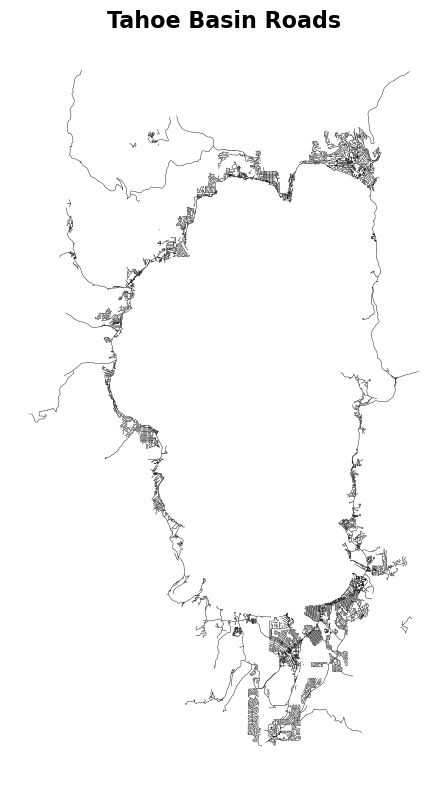

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
roads_gdf.to_crs('EPSG:3857').plot(ax=ax, color='k', linewidth=0.3)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('Tahoe Basin Roads', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tahoe_road_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Roads — bearing histogram and polar plot

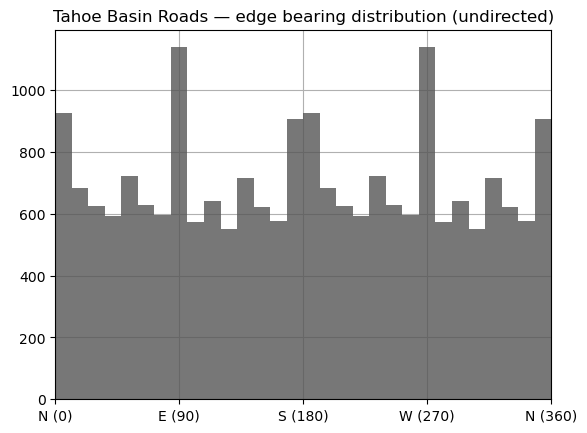

In [26]:
# Undirected bearings: include both forward and reverse so a N-S road contributes
# ~0° and ~180° regardless of which end was the digitization start point.
# This matches OSMnx notebook 17 behaviour.
road_bearings = pd.concat([
    roads_gdf['bearing'],
    (roads_gdf['bearing'] + 180) % 360,
], ignore_index=True)

ax = road_bearings.hist(bins=30, zorder=2, alpha=0.8, color='#555555')
ax.set_xlim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N (0)', 'E (90)', 'S (180)', 'W (270)', 'N (360)'])
ax.set_title('Tahoe Basin Roads — edge bearing distribution (undirected)')
plt.show()

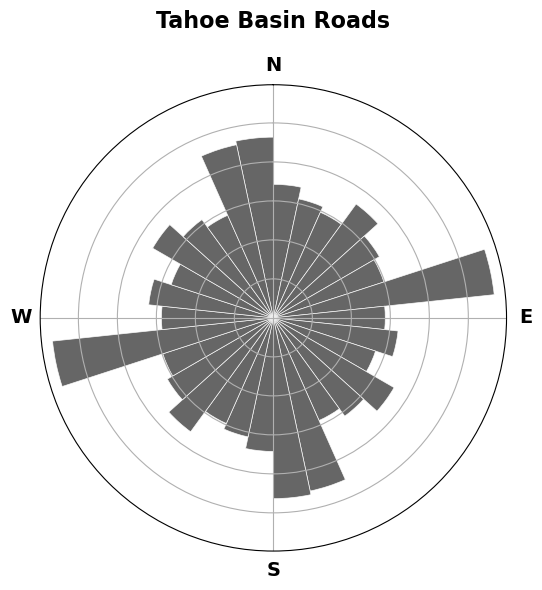

In [27]:
n = 30
count, division = np.histogram(road_bearings, bins=[ang * 360 / n for ang in range(0, n + 1)])
division = division[0:-1]
width = 2 * np.pi / n

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction('clockwise')
ax.bar(
    division * np.pi / 180 - width * 0.5, count,
    width=width, bottom=0.0,
    color='#555555', edgecolor='white', linewidth=0.5, alpha=0.9
)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2])
ax.set_xticklabels(['N', 'E', 'S', 'W'], fontsize=14, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Tahoe Basin Roads', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tahoe_bearing_polar_roads.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Trails — network map

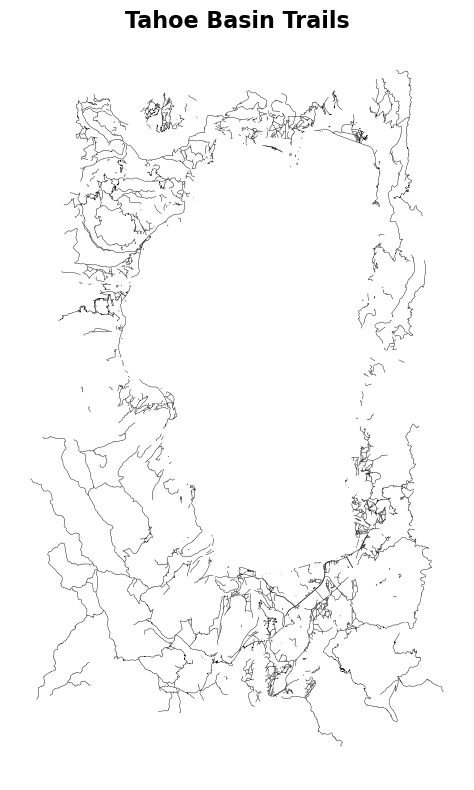

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
trails_gdf.to_crs('EPSG:3857').plot(ax=ax, color='k', linewidth=0.3)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('Tahoe Basin Trails', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tahoe_trail_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Trails — bearing histogram and polar plot

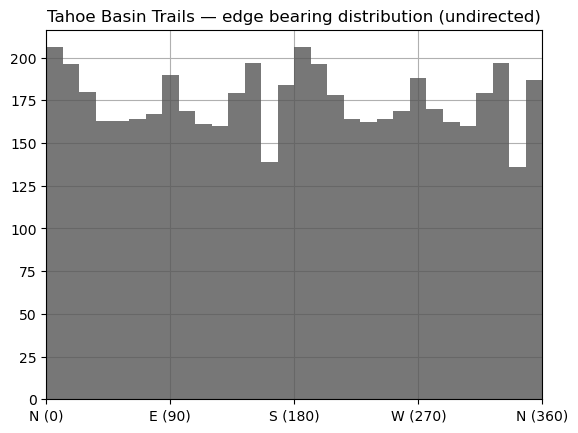

In [29]:
trail_bearings = pd.concat([
    trails_gdf['bearing'],
    (trails_gdf['bearing'] + 180) % 360,
], ignore_index=True)

ax = trail_bearings.hist(bins=30, zorder=2, alpha=0.8, color='#555555')
ax.set_xlim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N (0)', 'E (90)', 'S (180)', 'W (270)', 'N (360)'])
ax.set_title('Tahoe Basin Trails — edge bearing distribution (undirected)')
plt.show()

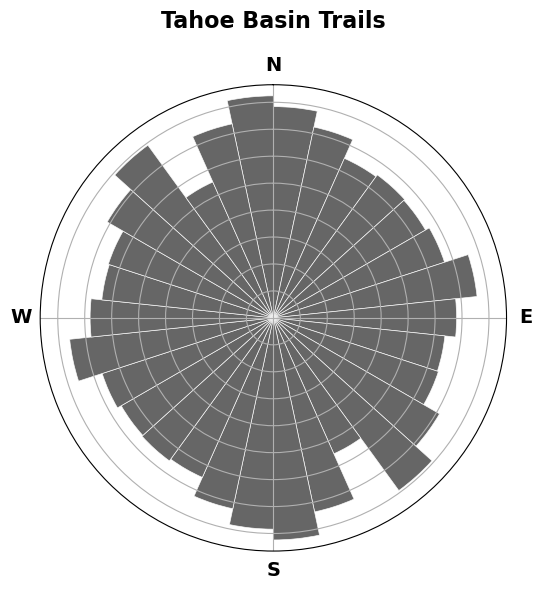

In [30]:
n = 30
count, division = np.histogram(trail_bearings, bins=[ang * 360 / n for ang in range(0, n + 1)])
division = division[0:-1]
width = 2 * np.pi / n

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction('clockwise')
ax.bar(
    division * np.pi / 180 - width * 0.5, count,
    width=width, bottom=0.0,
    color='#555555', edgecolor='white', linewidth=0.5, alpha=0.9
)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2])
ax.set_xticklabels(['N', 'E', 'S', 'W'], fontsize=14, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Tahoe Basin Trails', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tahoe_bearing_polar_trails.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Combined visualization

Two-column layout matching the reference style:
polar orientation plots (top row) + network maps (bottom row).

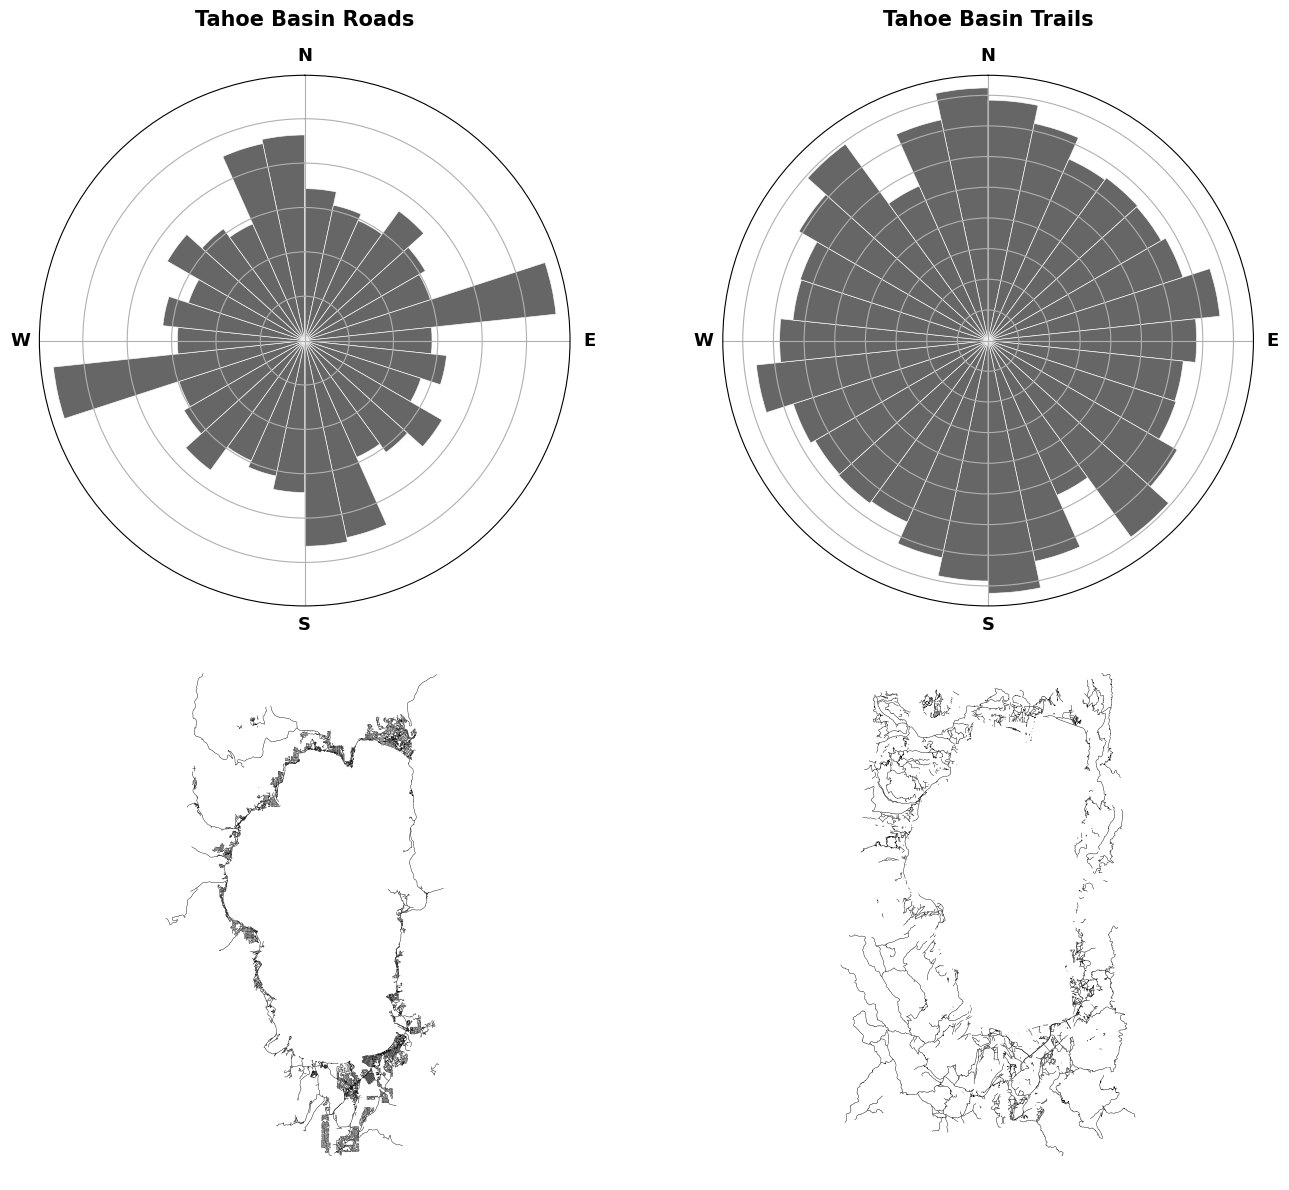

In [31]:
def _add_polar(ax, bearings, title, n=30):
    count, division = np.histogram(
        bearings, bins=[ang * 360 / n for ang in range(0, n + 1)]
    )
    division = division[0:-1]
    width = 2 * np.pi / n
    ax.set_theta_zero_location('N')
    ax.set_theta_direction('clockwise')
    ax.bar(
        division * np.pi / 180 - width * 0.5, count,
        width=width, bottom=0.0,
        color='#555555', edgecolor='white', linewidth=0.5, alpha=0.9
    )
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2])
    ax.set_xticklabels(['N', 'E', 'S', 'W'], fontsize=13, fontweight='bold')
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)


roads_wm  = roads_gdf.to_crs('EPSG:3857')
trails_wm = trails_gdf.to_crs('EPSG:3857')

fig = plt.figure(figsize=(14, 12))

# Top row: polar plots
ax_pr = fig.add_subplot(2, 2, 1, projection='polar')
ax_pt = fig.add_subplot(2, 2, 2, projection='polar')

# Bottom row: network maps
ax_mr = fig.add_subplot(2, 2, 3)
ax_mt = fig.add_subplot(2, 2, 4)

_add_polar(ax_pr, road_bearings,  'Tahoe Basin Roads')
_add_polar(ax_pt, trail_bearings, 'Tahoe Basin Trails')

roads_wm.plot(ax=ax_mr,  color='k', linewidth=0.3)
trails_wm.plot(ax=ax_mt, color='k', linewidth=0.3)

for ax in [ax_mr, ax_mt]:
    ax.set_aspect('equal')
    ax.set_axis_off()

plt.tight_layout()
plt.savefig('tahoe_bearing_combined.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8. Community-level analysis

Polar orientation + network map for each Tahoe community defined in `COMMUNITY_BBOXES`.
All data is re-clipped from `basin_gdf` — no re-download needed.

South Lake Tahoe: 2,925 road segments
Meyers: 592 road segments
Incline Village: 1,031 road segments
Kings Beach: 940 road segments


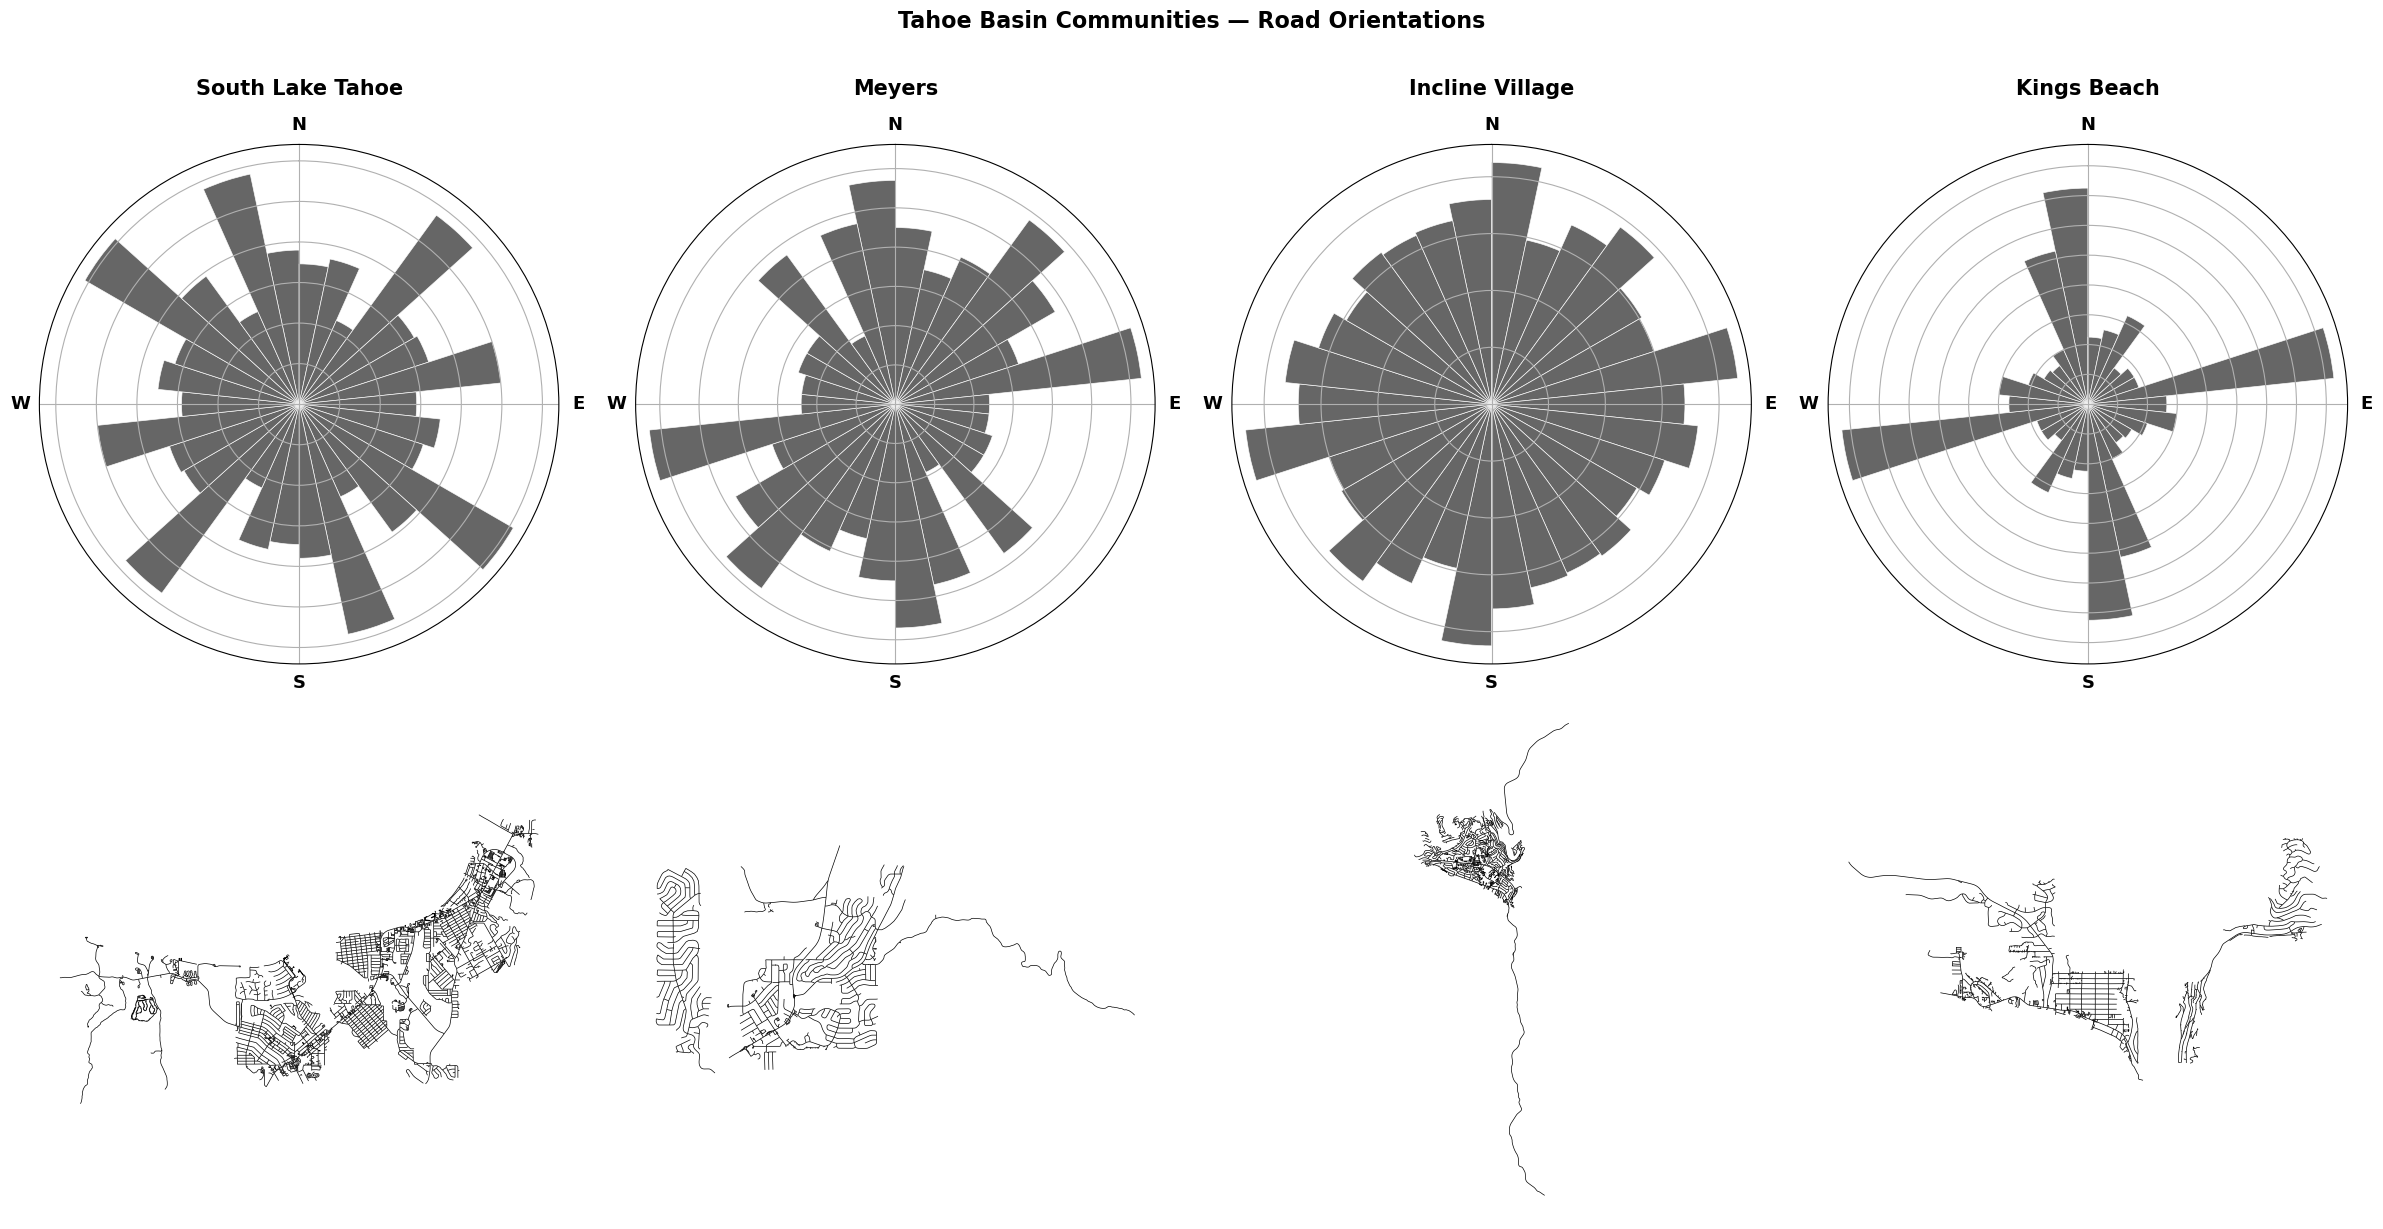

In [32]:
n_com = len(COMMUNITY_BBOXES)
fig   = plt.figure(figsize=(6 * n_com, 12))

for i, (cname, cbbox) in enumerate(COMMUNITY_BBOXES.items()):
    com_gdf   = basin_gdf.cx[cbbox[0]:cbbox[2], cbbox[1]:cbbox[3]]
    com_roads = add_edge_bearings(
        com_gdf[com_gdf['class'].isin(ROAD_CLASSES)].copy()
    )
    print(f"{cname}: {len(com_roads):,} road segments")

    # Undirected: forward + reverse
    com_bearings = pd.concat([
        com_roads['bearing'],
        (com_roads['bearing'] + 180) % 360,
    ], ignore_index=True)

    ax_p = fig.add_subplot(2, n_com, i + 1, projection='polar')
    _add_polar(ax_p, com_bearings, cname)

    ax_m = fig.add_subplot(2, n_com, n_com + i + 1)
    com_roads.to_crs('EPSG:3857').plot(ax=ax_m, color='k', linewidth=0.5)
    ax_m.set_aspect('equal')
    ax_m.set_axis_off()

plt.suptitle('Tahoe Basin Communities — Road Orientations',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tahoe_community_bearings.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()